# Main code for 46770 - Integrated Energy Grids
#### Group 8 - The Netherlands

### Libraries and Data

In [ ]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pypsa
from pathlib import Path
import logging

# Silence output from pypsa, linopy, and gurobipy
logging.getLogger("pypsa").setLevel(logging.WARNING)
logging.getLogger("linopy").setLevel(logging.WARNING)
logging.getLogger("gurobipy").setLevel(logging.WARNING)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Data path
FILE_DIR = Path.cwd()
DATA_DIR = FILE_DIR/"data"

# Load data
d_electricity = pd.read_csv(DATA_DIR/"electricity_demand.csv", parse_dates=["utc_time"], index_col="utc_time", sep=";") # Only 2015
CF_onshore = pd.read_csv(DATA_DIR/"onshore_CF.csv", parse_dates=["utc_time"], index_col="utc_time", sep=";")
CF_offshore = pd.read_csv(DATA_DIR/"offshore_CF.csv", parse_dates=["utc_time"], index_col="utc_time", sep=";")
CF_solar = pd.read_csv(DATA_DIR/"solar_CF.csv", parse_dates=["utc_time"], index_col="utc_time", sep=";")

# df_NLD
df_NLD = pd.DataFrame({
    "electricity_demand": d_electricity["NLD"].astype(float),
    "onshore_capacity_factor": CF_onshore["NLD"].astype(float),
    "offshore_capacity_factor": CF_offshore["NLD"].astype(float),
    "solar_capacity_factor": CF_solar["NLD"].astype(float)
})


ModuleNotFoundError: No module named 'pypsa'

### Functions

In [2]:
# Annuity function
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

# Create network function
def create_network(year, df):

    # --- Create demand (always 2015) ---
    e_demand = df['electricity_demand'].loc["2015"].iloc[:8760]

    # --- Copy & fix index ---
    df = df.copy().loc[str(year)].iloc[:8760]
    df.index = df.index.tz_localize(None)

    e_demand.index = df.index

    # --- Create network ---
    n = pypsa.Network(name=f"Netherlands {year}")
    n.set_snapshots(df.index)

    # --- Carriers ---
    carriers = {
        "AC": 0,
        "Wind_onshore": 0,
        "Wind_offshore": 0,
        "Solar": 0,
        "Coal": 0.812,
        "Gas": 0.478,
    }

    for carrier, co2 in carriers.items():
        n.add("Carrier", carrier, co2_emissions=co2)

    # --- Bus ---
    n.add("Bus", "NLD", carrier="AC")

    # --- Generators ---
    n.add(
        "Generator",
        "NLD onshore wind",
        bus="NLD",
        carrier="Wind_onshore",
        marginal_cost=0,
        capital_cost=902000 * annuity(0.07, 25),
        p_max_pu=df["onshore_capacity_factor"],
        p_nom_extendable=True,
    )

    n.add(
        "Generator",
        "NLD offshore wind",
        bus="NLD",
        carrier="Wind_offshore",
        marginal_cost=0,
        capital_cost=2481000 * annuity(0.07, 25),
        p_max_pu=df["offshore_capacity_factor"],
        p_nom_extendable=True,
    )

    n.add(
        "Generator",
        "NLD solar",
        bus="NLD",
        carrier="Solar",
        marginal_cost=0,
        capital_cost=599000 * annuity(0.07, 30),
        p_max_pu=df["solar_capacity_factor"],
        p_nom_extendable=True,
    )

    n.add(
        "Generator",
        "NLD coal",
        bus="NLD",
        carrier="Coal",
        marginal_cost=34.8,
        capital_cost=3828000 * annuity(0.07, 50),
        p_nom_extendable=True,
    )

    n.add(
        "Generator",
        "NLD gas",
        bus="NLD",
        carrier="Gas",
        marginal_cost=41.8,
        capital_cost=890000 * annuity(0.07, 30),
        p_nom_extendable=True,
    )

    # --- Load ---
    n.add(
        "Load",
        "NLD load",
        bus="NLD",
        carrier="AC",
        p_set=e_demand,
    )

    return n

## a)
### Optimal Capacities 2015

In [3]:
# Create network
n15 = create_network(2015, df_NLD)

# --- Solve ---
n15.optimize(solver_name="gurobi",
           solver_options={"LogToConsole": 0, "OutputFlag": 0})
n15.statistics()  # View results

Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 123.49it/s]

Set parameter Username
Set parameter LicenseID to value 2706901
Academic license - for non-commercial use only - expires 2026-09-10
Read LP format model from file C:\Users\s223865\AppData\Local\Temp\linopy-problem-8jtch0a0.lp


Reading time = 0.24 seconds
obj: 96365 rows, 43805 columns, 170814 nonzeros
Set parameter LogToConsole to value 0


Optimal Capacity  Installed Capacity        Supply  \
Generator Coal                    0.00000                 0.0  0.000000e+00   
          Gas                 17405.66848                 0.0  7.903452e+07   
          Solar                   0.00000                 0.0  0.000000e+00   
          Wind_offshore           0.00000                 0.0  0.000000e+00   
          Wind_onshore        16592.39130                 0.0  3.421536e+07   
Load      AC                      0.00000                 0.0  0.000000e+00   

                          Withdrawal  Energy Balance Transmission  \
Generator Coal                   0.0    0.000000e+00          0.0   
          Gas                    0.0    7.903452e+07          0.0   
          Solar                  0.0    0.000000e+00          0.0   
          Wind_offshore          0.0    0.000000e+00          0.0   
          Wind_onshore           0.0    3.421536e+07          0.0   
Load      AC             113249877.0   -1.132499e+08          0.0   

                         Capacity Factor   Curtailment  Capital Expenditure  \
Generator Coal                  0.000000  0.000000e+00         0.000000e+00   
          Gas                   0.518349  7.343913e+07         1.248368e+09   
          Solar                 0.000000  0.000000e+00         0.000000e+00   
          Wind_offshore         0.000000  0.000000e+00         0.000000e+00   
          Wind_onshore          0.235401  5.921956e+05         1.284269e+09   
Load      AC                         NaN  0.000000e+00         0.000000e+00   

                         Operational Expenditure       Revenue  Market Value  
Generator Coal                      0.000000e+00  0.000000e+00           NaN  
          Gas                       3.303643e+09  4.552011e+09     57.595219  
          Solar                     0.000000e+00  0.000000e+00           NaN  
          Wind_offshore             0.000000e+00  0.000000e+00           NaN  
          Wind_onshore              0.000000e+00  1.284269e+09     37.534875  
Load      AC                        0.000000e+00 -5.836280e+09    -51.534534

### Plots

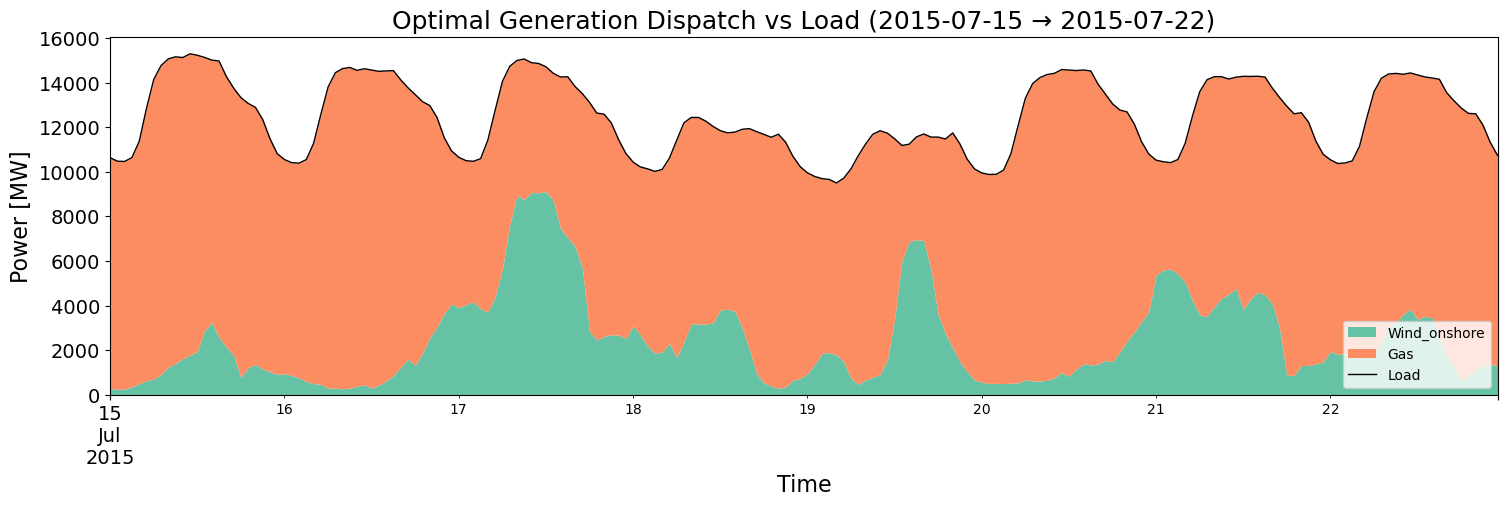

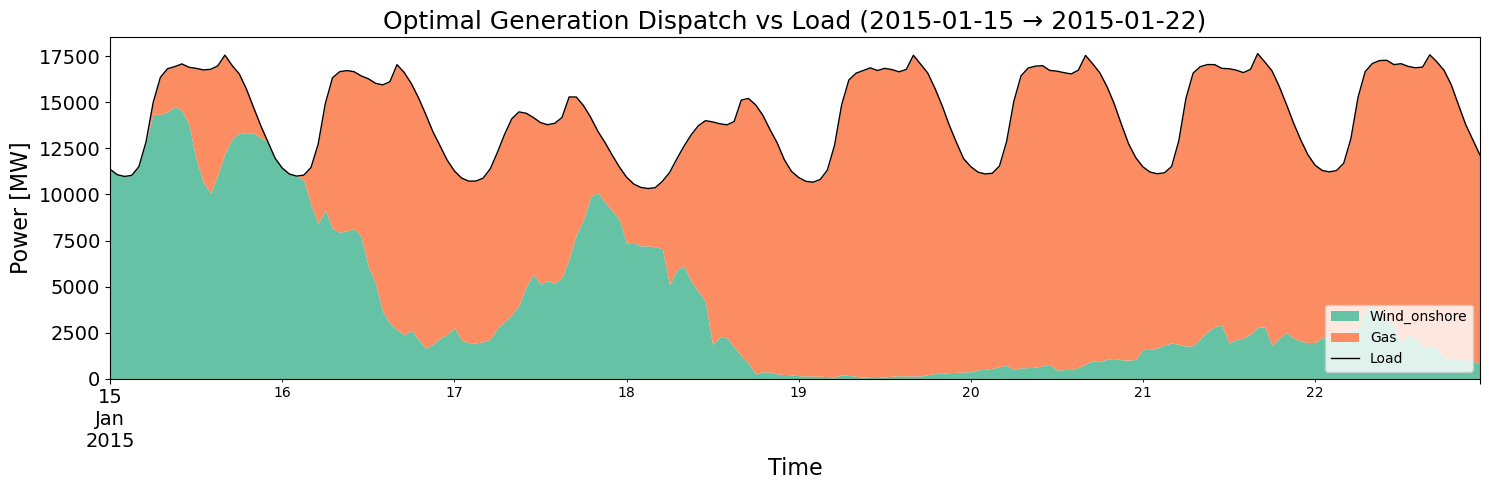

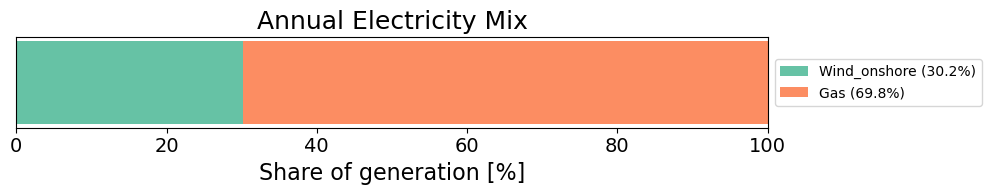

In [4]:
# Colors
carrier_colors = {
    "Wind_onshore": "#66c2a5",
    "Wind_offshore": "#3288bd",
    "Solar": "#ffd92f",
    "Gas": "#fc8d62",
    "Coal": "#4d4d4d",
}

# Define stack order for plotting: bottom -> top
stack_order = ["Wind_onshore", "Wind_offshore", "Solar", "Coal", "Gas"]

# ---------------------
# SUMMER WEEK
# ---------------------

# --- Set start and end date for plotting ---
start_date = "2015-07-15"
end_date   = "2015-07-22"

# --- Apply mask ---
gen_dispatch = n15.generators_t.p.loc[start_date:end_date]
load = n15.loads_t.p_set.loc[start_date:end_date]

# --- Group by carrier ---
gen_dispatch_carrier = gen_dispatch.T.groupby(n15.generators.carrier).sum().T

# --- Keep only carriers that actually generate power ---
gen_dispatch_carrier = gen_dispatch_carrier.loc[:, gen_dispatch_carrier.sum() > 0]

# --- Reorder columns to match stack order ---
gen_dispatch_carrier = gen_dispatch_carrier[[c for c in stack_order if c in gen_dispatch_carrier.columns]]

plt.figure(figsize=(15,5))

gen_dispatch_carrier.plot.area(
    ax=plt.gca(),
    linewidth=0,
    color=[carrier_colors[c] for c in gen_dispatch_carrier.columns]
)

(load.sum(axis=1)).plot(ax=plt.gca(), color='k', linewidth=1, label='Load')

plt.ylabel("Power [MW]", fontsize=16)
plt.xlabel("Time", fontsize=16)
plt.title(f"Optimal Generation Dispatch vs Load ({start_date} → {end_date})", fontsize=18)
plt.legend(loc="lower right")
plt.tight_layout()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

# ---------------------
# WINTER WEEK
# ---------------------

# --- Set start and end date for plotting ---
start_date = "2015-01-15"
end_date   = "2015-01-22"

# --- Apply mask ---
gen_dispatch = n15.generators_t.p.loc[start_date:end_date]
load = n15.loads_t.p_set.loc[start_date:end_date]

# --- Group by carrier ---
gen_dispatch_carrier = gen_dispatch.T.groupby(n15.generators.carrier).sum().T

# --- Keep only carriers that actually generate power ---
gen_dispatch_carrier = gen_dispatch_carrier.loc[:, gen_dispatch_carrier.sum() > 0]

# --- Reorder columns to match stack order ---
gen_dispatch_carrier = gen_dispatch_carrier[[c for c in stack_order if c in gen_dispatch_carrier.columns]]

plt.figure(figsize=(15,5))

gen_dispatch_carrier.plot.area(
    ax=plt.gca(),
    linewidth=0,
    color=[carrier_colors[c] for c in gen_dispatch_carrier.columns]
)

(load.sum(axis=1)).plot(ax=plt.gca(), color='k', linewidth=1, label='Load')

plt.ylabel("Power [MW]", fontsize=16)
plt.xlabel("Time", fontsize=16)
plt.title(f"Optimal Generation Dispatch vs Load ({start_date} → {end_date})", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ---------------------
# ANNUAL ELECTRICITY MIX
# ---------------------

# --- Slice generation ---
gen_dispatch = n15.generators_t.p

# --- Aggregate by carrier ---
carrier_map = n15.generators.carrier
gen_energy = gen_dispatch.sum().groupby(carrier_map).sum()

# --- Convert to percentage ---
gen_share = gen_energy / gen_energy.sum() * 100
gen_share = gen_share[gen_share > 1e-6]

# --- Keep order consistent with stack_order ---
gen_share = gen_share.reindex([c for c in stack_order if c in gen_share]).dropna()

# --- Plot ---
fig, ax = plt.subplots(figsize=(10,2))

left = 0
for carrier, value in gen_share.items():
    ax.barh(
        0,
        value,
        left=left,
        color=carrier_colors.get(carrier, "gray"),
        label=f"{carrier} ({value:.1f}%)"
    )
    left += value

ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel("Share of generation [%]", fontsize=16)
ax.set_title(f"Annual Electricity Mix", fontsize=18)

ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.xticks(fontsize=14)
plt.show()

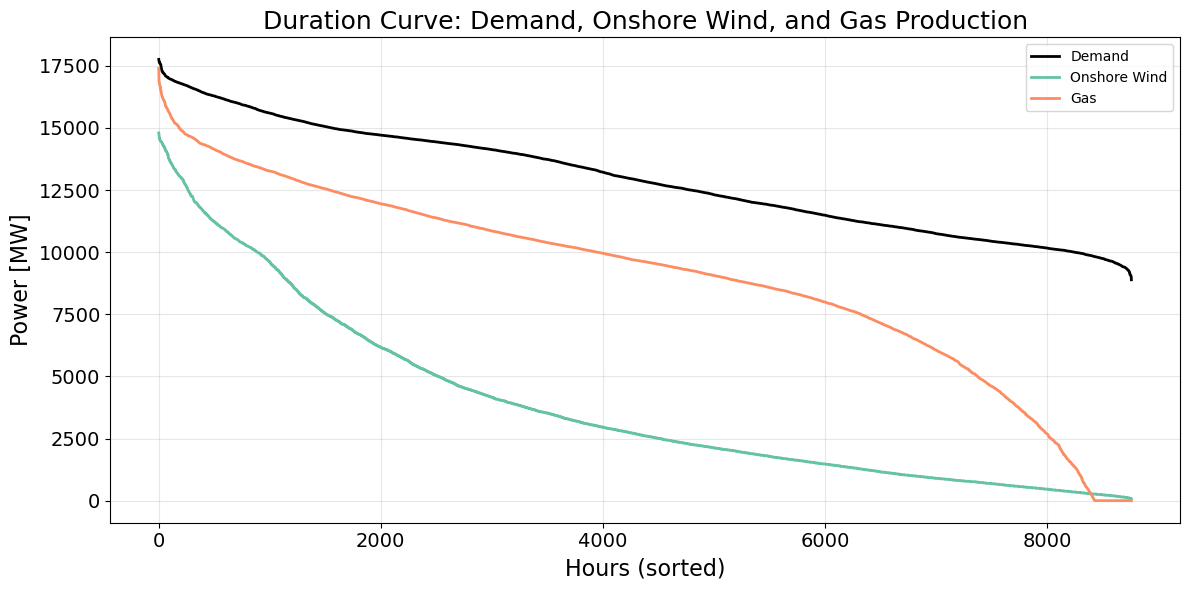

In [5]:
# ---------------------
# DURATION CURVE: Demand, Onshore Wind, Gas
# ---------------------

# --- Select time period (full year or a week) ---
start_date = "2015-01-01"
end_date   = "2015-12-31"

# --- Slice generation and load ---
gen_dispatch = n15.generators_t.p.loc[start_date:end_date]
load = n15.loads_t.p_set.loc[start_date:end_date]

# --- Aggregate by carrier ---
gen_dispatch_carrier = gen_dispatch.T.groupby(n15.generators.carrier).sum().T

# --- Extract series ---
demand_series = load.sum(axis=1)
wind_onshore_series = gen_dispatch_carrier.get("Wind_onshore", pd.Series(0, index=demand_series.index))
gas_series = gen_dispatch_carrier.get("Gas", pd.Series(0, index=demand_series.index))

# --- Sort for duration curve (descending) ---
demand_sorted = demand_series.sort_values(ascending=False).reset_index(drop=True)
wind_sorted   = wind_onshore_series.sort_values(ascending=False).reset_index(drop=True)
gas_sorted    = gas_series.sort_values(ascending=False).reset_index(drop=True)

# --- Plot ---
plt.figure(figsize=(12,6))

plt.plot(demand_sorted, label="Demand", color="k", linewidth=2)
plt.plot(wind_sorted, label="Onshore Wind", color="#66c2a5", linewidth=2)
plt.plot(gas_sorted, label="Gas", color="#fc8d62", linewidth=2)

plt.xlabel("Hours (sorted)", fontsize=16)
plt.ylabel("Power [MW]", fontsize=16)
plt.title("Duration Curve: Demand, Onshore Wind, and Gas Production", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## b)
### Interannual variability

In [6]:
df_results = []

for year in CF_onshore.index.year.unique():
    
    # Create model for the year
    n = create_network(year, df_NLD)

    # Set snapshots to current year
    snapshots = CF_onshore.loc[str(year)].index.tz_localize(None)
    n.set_snapshots(snapshots)

    # --- Solve optimization ---
    n.optimize(solver_name="gurobi",
               solver_options={"LogToConsole": 0, "OutputFlag": 0},
               progress=False)
    
    # --- Record results ---
    df_results.append({
        "year": year,
        "onshore_capacity": n.generators.p_nom_opt["NLD onshore wind"],
        "offshore_capacity": n.generators.p_nom_opt["NLD offshore wind"],
        "solar_capacity": n.generators.p_nom_opt["NLD solar"],
        "coal_capacity": n.generators.p_nom_opt["NLD coal"],
        "gas_capacity": n.generators.p_nom_opt["NLD gas"]
    })

# Convert to DataFrame
df_results = pd.DataFrame(df_results)

Set parameter Username
Set parameter LicenseID to value 2706901
Academic license - for non-commercial use only - expires 2026-09-10
Read LP format model from file C:\Users\s223865\AppData\Local\Temp\linopy-problem-ud52qw58.lp
Reading time = 0.89 seconds
obj: 96365 rows, 43805 columns, 170808 nonzeros
Set parameter LogToConsole to value 0
Set parameter Username
Set parameter LicenseID to value 2706901
Academic license - for non-commercial use only - expires 2026-09-10
Read LP format model from file C:\Users\s223865\AppData\Local\Temp\linopy-problem-94q9qq88.lp
Reading time = 0.22 seconds
obj: 96629 rows, 43925 columns, 171287 nonzeros
Set parameter LogToConsole to value 0
Set parameter Username
Set parameter LicenseID to value 2706901
Academic license - for non-commercial use only - expires 2026-09-10
Read LP format model from file C:\Users\s223865\AppData\Local\Temp\linopy-problem-07nxo2wk.lp
Reading time = 0.37 seconds
obj: 96365 rows, 43805 columns, 170801 nonzeros
Set parameter LogT

C:\Users\s223865\AppData\Local\Temp\ipykernel_65264\2666191360.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(


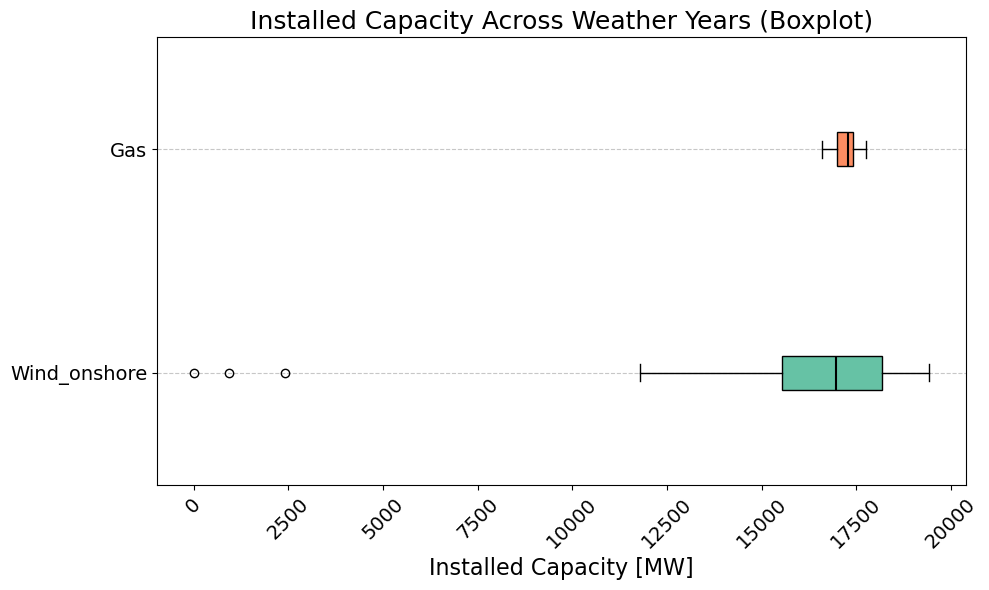

In [7]:
# -------------------------
# Plotting sensitivity
# -------------------------

# List of generators and corresponding carriers
gens = ["onshore_capacity", "offshore_capacity", "solar_capacity", "coal_capacity", "gas_capacity"]
carrier_map = {
    "onshore_capacity": "Wind_onshore",
    "offshore_capacity": "Wind_offshore",
    "solar_capacity": "Solar",
    "coal_capacity": "Coal",
    "gas_capacity": "Gas",
}

# Keep only generators deployed in at least one year
deployed_gens = [g for g in gens if df_results[g].max() > 0]

# Reorder according to your stack_order
deployed_gens = sorted(
    deployed_gens, 
    key=lambda x: stack_order.index(carrier_map[x]) if carrier_map[x] in stack_order else 99
)


box_data = [df_results[g] for g in deployed_gens]
box_labels = [carrier_map[g] for g in deployed_gens]
box_colors = [carrier_colors[c] for c in box_labels]

fig, ax = plt.subplots(figsize=(10,6))

bplot = ax.boxplot(
    box_data,
    patch_artist=True,
    labels=box_labels,
    medianprops=dict(color='black', linewidth=1.5),
    vert=False
)

# Fill colors
for patch, color in zip(bplot['boxes'], box_colors):
    patch.set_facecolor(color)

# Styling
ax.set_xlabel("Installed Capacity [MW]", fontsize=16)
ax.set_title("Installed Capacity Across Weather Years (Boxplot)", fontsize=18)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

## c)
### Energy Storage System

In [16]:
energy_cost = 110*1000 # €/MWh
battery_hours = 4 # hours (change this to either 4, 6, or 8)
# PyPSA requires capital cost in €/MW, so we need to convert the energy cost to power cost
CAPEX_per_kW = (energy_cost * battery_hours)*annuity(0.07, 10) # €/MW  # 10 years expected lifetime

# Creating network (nc = network for part c)
nc = create_network(2015, df_NLD)

# This should be added to the PyPSA network
nc.add("StorageUnit",
            name="battery",
            carrier="battery",
            bus="NLD",
            p_nom_extendable=True,
            max_hours=battery_hours,
            capital_cost=CAPEX_per_kW,
            marginal_cost=0,
            efficiency_store=0.95,
            efficiency_dispatch=0.95)

nc.optimize(solver_name="gurobi",
               solver_options={"LogToConsole": 0, "OutputFlag": 0},
               progress=False)

nc.statistics()

Index(['battery'], dtype='str', name='name')


Set parameter Username
Set parameter LicenseID to value 2706901
Academic license - for non-commercial use only - expires 2026-09-10
Read LP format model from file C:\Users\s223865\AppData\Local\Temp\linopy-problem-xi79c45b.lp
Reading time = 0.28 seconds
obj: 157686 rows, 70086 columns, 302214 nonzeros
Set parameter LogToConsole to value 0


Optimal Capacity  Installed Capacity        Supply  \
Generator   Coal                    0.00000                 0.0  0.000000e+00   
            Gas                 16112.67254                 0.0  7.776424e+07   
            Solar                 599.55841                 0.0  6.213913e+05   
            Wind_offshore           0.00000                 0.0  0.000000e+00   
            Wind_onshore        16853.28638                 0.0  3.488404e+07   
Load        AC                      0.00000                 0.0  0.000000e+00   
StorageUnit battery              1290.64789                 0.0  1.832336e+05   

                             Withdrawal  Energy Balance Transmission  \
Generator   Coal           0.000000e+00    0.000000e+00          0.0   
            Gas            0.000000e+00    7.776424e+07          0.0   
            Solar          0.000000e+00    6.213913e+05          0.0   
            Wind_offshore  0.000000e+00    0.000000e+00          0.0   
            Wind_onshore   0.000000e+00    3.488404e+07          0.0   
Load        AC             1.132499e+08   -1.132499e+08          0.0   
StorageUnit battery        2.030290e+05   -1.979532e+04          0.0   

                           Capacity Factor   Curtailment  Capital Expenditure  \
Generator   Coal                  0.000000  0.000000e+00         0.000000e+00   
            Gas                   0.550945  6.338277e+07         1.155631e+09   
            Solar                 0.118312  1.798680e+00         2.894144e+07   
            Wind_offshore         0.000000  0.000000e+00         0.000000e+00   
            Wind_onshore          0.236286  4.708147e+05         1.304463e+09   
Load        AC                         NaN  0.000000e+00         0.000000e+00   
StorageUnit battery               0.034164  1.132587e+07         8.085406e+07   

                           Operational Expenditure       Revenue  Market Value  
Generator   Coal                      0.000000e+00  0.000000e+00           NaN  
            Gas                       3.250545e+09  4.406177e+09     56.660706  
            Solar                     0.000000e+00  2.894144e+07     46.575221  
            Wind_offshore             0.000000e+00  0.000000e+00           NaN  
            Wind_onshore              0.000000e+00  1.304463e+09     37.394251  
Load        AC                        0.000000e+00 -5.820435e+09    -51.394623  
StorageUnit battery                   0.000000e+00  8.085406e+07    209.324086

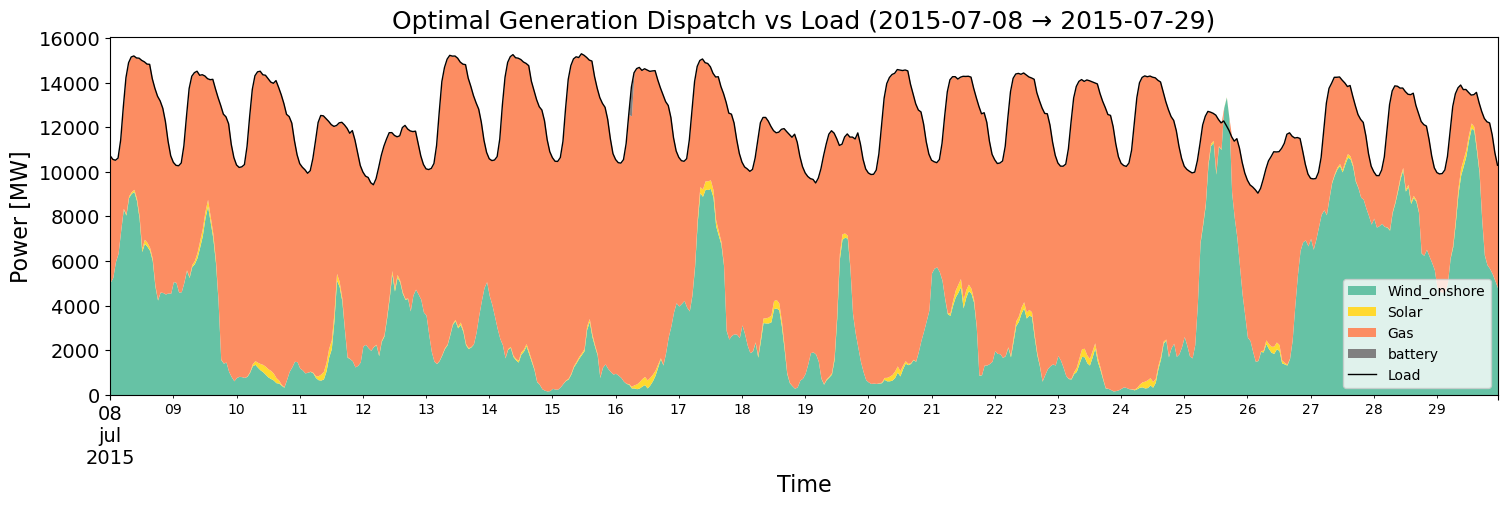

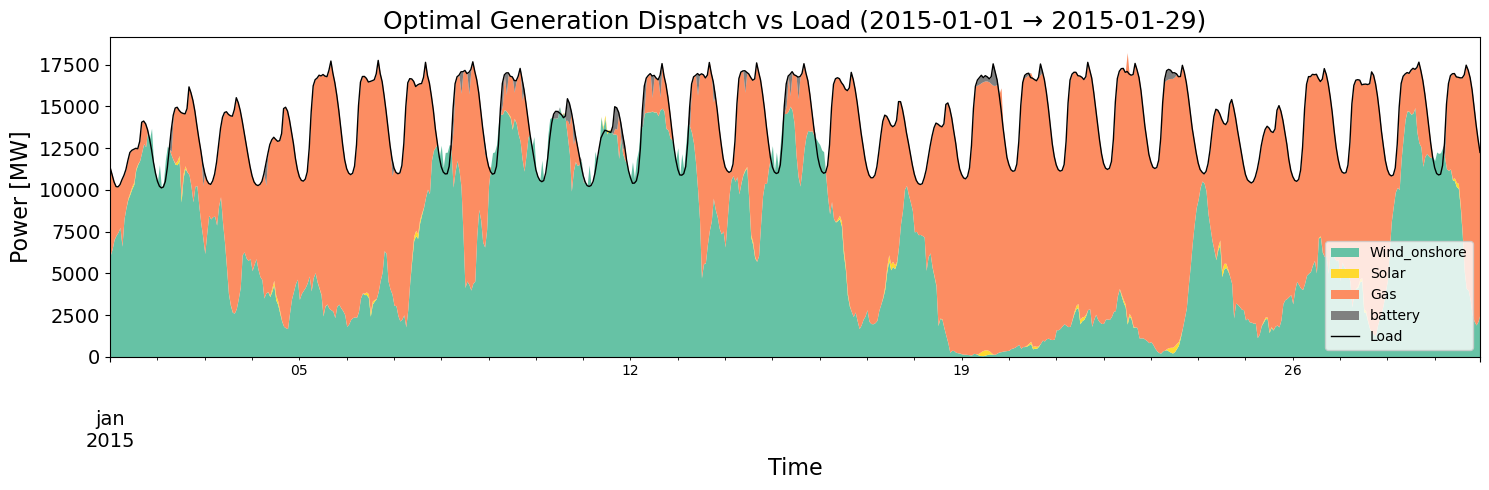

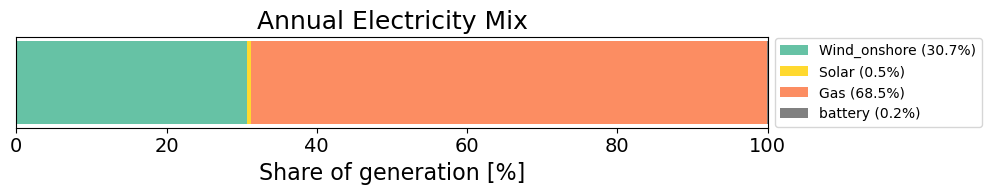

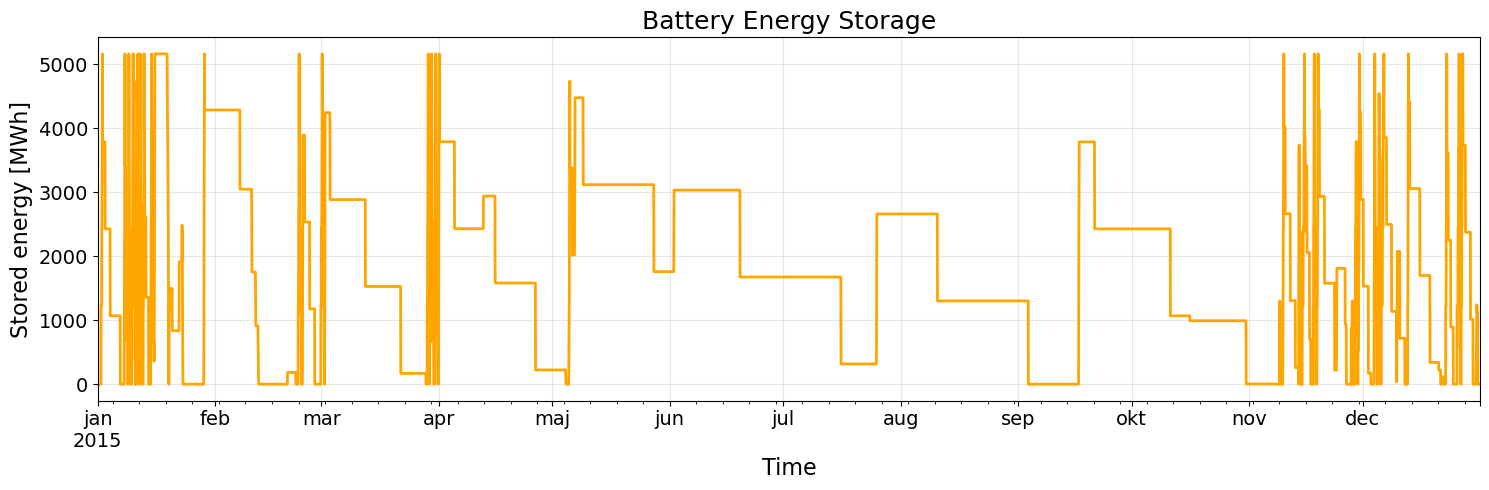

In [17]:
# ---------------------
# SUMMER WEEK
# ---------------------

# --- Set start and end date for plotting ---
start_date = "2015-07-08"
end_date   = "2015-07-29"

# --- Apply mask ---
gen_dispatch = nc.generators_t.p.loc[start_date:end_date]
load = nc.loads_t.p_set.loc[start_date:end_date]

# --- Include battery discharging only ---
if "battery" in nc.storage_units.index:
    battery_discharge = nc.storage_units_t.p.loc[start_date:end_date, "battery"].clip(lower=0)
    gen_dispatch["battery"] = battery_discharge

# --- Group by carrier ---
gen_dispatch_carrier = gen_dispatch.T.groupby(lambda x: nc.generators.carrier.get(x, x)).sum().T

# --- Keep only carriers that actually generate power ---
gen_dispatch_carrier = gen_dispatch_carrier.loc[:, gen_dispatch_carrier.sum() > 0]

# --- Reorder columns to match stack order ---
stack_order_with_battery = stack_order + ["battery"]
gen_dispatch_carrier = gen_dispatch_carrier[[c for c in stack_order_with_battery if c in gen_dispatch_carrier.columns]]

plt.figure(figsize=(15,5))

gen_dispatch_carrier.plot.area(
    ax=plt.gca(),
    linewidth=0,
    color=[carrier_colors.get(c, "gray") for c in gen_dispatch_carrier.columns]
)

(load.sum(axis=1)).plot(ax=plt.gca(), color='k', linewidth=1, label='Load')

plt.ylabel("Power [MW]", fontsize=16)
plt.xlabel("Time", fontsize=16)
plt.title(f"Optimal Generation Dispatch vs Load ({start_date} → {end_date})", fontsize=18)
plt.legend(loc="lower right")
plt.tight_layout()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

# ---------------------
# WINTER WEEK
# ---------------------

# --- Set start and end date for plotting ---
start_date = "2015-01-01"
end_date   = "2015-01-29"

# --- Apply mask ---
gen_dispatch = nc.generators_t.p.loc[start_date:end_date]
load = nc.loads_t.p_set.loc[start_date:end_date]

# --- Include battery discharging only ---
if "battery" in nc.storage_units.index:
    battery_discharge = nc.storage_units_t.p.loc[start_date:end_date, "battery"].clip(lower=0)
    gen_dispatch["battery"] = battery_discharge

# --- Group by carrier ---
gen_dispatch_carrier = gen_dispatch.T.groupby(lambda x: nc.generators.carrier.get(x, x)).sum().T

# --- Keep only carriers that actually generate power ---
gen_dispatch_carrier = gen_dispatch_carrier.loc[:, gen_dispatch_carrier.sum() > 0]

# --- Reorder columns to match stack order ---
stack_order_with_battery = stack_order + ["battery"]
gen_dispatch_carrier = gen_dispatch_carrier[[c for c in stack_order_with_battery if c in gen_dispatch_carrier.columns]]

plt.figure(figsize=(15,5))

gen_dispatch_carrier.plot.area(
    ax=plt.gca(),
    linewidth=0,
    color=[carrier_colors.get(c, "gray") for c in gen_dispatch_carrier.columns]
)

(load.sum(axis=1)).plot(ax=plt.gca(), color='k', linewidth=1, label='Load')

plt.ylabel("Power [MW]", fontsize=16)
plt.xlabel("Time", fontsize=16)
plt.title(f"Optimal Generation Dispatch vs Load ({start_date} → {end_date})", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ---------------------
# ANNUAL ELECTRICITY MIX
# ---------------------

# --- Slice generation ---
gen_dispatch = nc.generators_t.p.copy()

# --- Include battery discharging only ---
if "battery" in nc.storage_units.index:
    gen_dispatch["battery"] = nc.storage_units_t.p.clip(lower=0)

# --- Aggregate by carrier ---
carrier_map = nc.generators.carrier.to_dict()
carrier_map.update({"battery": "battery"})

gen_energy = gen_dispatch.sum().groupby(lambda x: carrier_map.get(x, x)).sum()

# --- Convert to percentage ---
gen_share = gen_energy / gen_energy.sum() * 100
gen_share = gen_share[gen_share > 1e-6]

# --- Keep order consistent with stack_order ---
stack_order_with_battery = stack_order + ["battery"]
gen_share = gen_share.reindex([c for c in stack_order_with_battery if c in gen_share]).dropna()

# --- Plot ---
fig, ax = plt.subplots(figsize=(10,2))

left = 0
for carrier, value in gen_share.items():
    ax.barh(
        0,
        value,
        left=left,
        color=carrier_colors.get(carrier, "gray"),
        label=f"{carrier} ({value:.1f}%)"
    )
    left += value

ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel("Share of generation [%]", fontsize=16)
ax.set_title(f"Annual Electricity Mix", fontsize=18)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.xticks(fontsize=14)
plt.show()

# ---------------------
# BATTERY STATE OF CHARGE (SOC) TIMESERIES
# ---------------------

# --- Select the battery storage unit ---
battery_name = "battery"

# --- Slice the SoC time series for the whole year ---
soc = nc.storage_units_t.state_of_charge[battery_name]


#focus on a particular week or month
#start_date = "2015-07-01"
#end_date   = "2015-07-08"
#soc = soc.loc[start_date:end_date]

# --- Plot ---
plt.figure(figsize=(15,5))
soc.plot(color='orange', linewidth=2)
plt.xlabel("Time", fontsize=16)
plt.ylabel("Stored energy [MWh]", fontsize=16)
plt.title(f"Battery Energy Storage", fontsize=18)
plt.grid(True, alpha=0.3)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

## d)
#### Connecting to Denmark, Germany and Belgium

In [8]:
# Interconnecter capacities:
cap_DNK_NLD = 700  #MW
cap_DEU_NLD = 3950 #MW
cap_BEL_NLD = 1400 #MW
cap_DEU_DNK = 3500 #MW
cap_BEL_DEU = 1000 #MW

# Capacity factors for 2015
CF_onshore_2015  = CF_onshore.loc["2015"]
CF_offshore_2015 = CF_offshore.loc["2015"]
CF_solar_2015    = CF_solar.loc["2015"]

# Network voltage
V_level = 400 #kV

# Reactance
x_react = 0.1

# Resistance
r_resis = 0.01

# Creating network (nd = network for part d)
nd = create_network(2015, df_NLD)
nd.name = "NLD interconnected"

# Adding other countries as buses
nd.add("Bus", "DEU", V_nom=V_level)
nd.add("Bus", "BEL", V_nom=V_level)
nd.add("Bus", "DNK", V_nom=V_level)

# Network lines
nd.add("Line", "line DNK-NLD", bus0 = "DNK", bus1 = "NLD", s_nom = cap_DNK_NLD, x=x_react, r=r_resis) # Line 1
nd.add("Line", "line DEU-NLD", bus0 = "DEU", bus1 = "NLD", s_nom = cap_DEU_NLD, x=x_react, r=r_resis) # Line 2
nd.add("Line", "line BEL-NLD", bus0 = "BEL", bus1 = "NLD", s_nom = cap_BEL_NLD, x=x_react, r=r_resis) # Line 3
nd.add("Line", "line DEU-DNK", bus0 = "DEU", bus1 = "DNK", s_nom = cap_DEU_DNK, x=x_react, r=r_resis) # Line 4
nd.add("Line", "line BEL-DEU", bus0 = "BEL", bus1 = "DEU", s_nom = cap_BEL_DEU, x=x_react, r=r_resis) # Line 5

# Generator technology data:
tech_data = {
    "Coal":         {"capex": 3828, "lifetime": 50, "marginal_cost": 34.8, "co2": 0.812, "countries": ["DEU", "DNK"]},
    "Gas":          {"capex": 890,  "lifetime": 30, "marginal_cost": 41.8, "co2": 0.478, "countries": ["DEU", "BEL"]},
    "Wind_onshore": {"capex": 902,  "lifetime": 25, "marginal_cost": 0,    "co2": 0,     "countries": ["DEU", "DNK", "BEL"]},
    "Wind_offshore":{"capex": 2481, "lifetime": 25, "marginal_cost": 0,    "co2": 0,     "countries": ["DEU", "DNK", "BEL"]},
    "Solar":        {"capex": 599,  "lifetime": 30, "marginal_cost": 0,    "co2": 0,     "countries": ["DEU", "DNK", "BEL"]},
    "Biofuel":      {"capex": 1950, "lifetime": 20, "marginal_cost": 35,   "co2": 0,     "countries": ["DEU", "DNK"]},
    "Nuclear":      {"capex": 4000, "lifetime": 60, "marginal_cost": 12,   "co2": 0,     "countries": ["BEL"]}
}

for tech, data in tech_data.items():
    data["capital_cost"] = data["capex"] * 1000 * annuity(0.07, data["lifetime"])

# Adding loads
for country in ["DEU", "BEL", "DNK"]:
    nd.add("Load",
           f"{country} load",
           bus=country,
           p_set=d_electricity[country].tz_localize(None))

# Adding generators
for tech, data in tech_data.items():
    for country in data["countries"]:

        gen_name = f"{tech}_{country}"

        kwargs = {
            "bus": country,
            "p_nom": 0,  # or extendable
            "marginal_cost": data["marginal_cost"],
            "capital_cost": data["capital_cost"],
            "carrier": tech,
            "p_nom_extendable": True,
        }

        # Attach capacity factors for renewables
        if tech == "Wind_onshore":
            kwargs["p_max_pu"] = CF_onshore_2015[country].tz_localize(None)

        elif tech == "Wind_offshore":
            kwargs["p_max_pu"] = CF_offshore_2015[country].tz_localize(None)

        elif tech == "Solar":
            kwargs["p_max_pu"] = CF_solar_2015[country].tz_localize(None)

        nd.add("Generator", gen_name, **kwargs)

nd.optimize()

nd.statistics()

Index(['Biofuel_DEU', 'Biofuel_DNK', 'Nuclear_BEL'], dtype='str', name='name')
Writing continuous variables.: 100%|██████████| 3/3 [00:00<00:00, 116.40it/s]


Optimal Capacity  Installed Capacity        Supply  \
Generator Biofuel              1603.81094                 0.0  1.105565e+07   
          Coal                    0.00000                 0.0  0.000000e+00   
          Gas                 97734.00928                 0.0  4.535065e+08   
          Nuclear              9813.01199                 0.0  8.444008e+07   
          Solar                   0.00000                 0.0  0.000000e+00   
          Wind_offshore           0.00000                 0.0  0.000000e+00   
          Wind_onshore        95183.35279                 0.0  1.875471e+08   
Line      AC                  10550.00000             10550.0  2.262644e+07   
Load      -                       0.00000                 0.0  0.000000e+00   
          AC                      0.00000                 0.0  0.000000e+00   

                           Withdrawal  Energy Balance  Transmission  \
Generator Biofuel        0.000000e+00    1.105565e+07       0.00000   
          Coal           0.000000e+00    0.000000e+00       0.00000   
          Gas            0.000000e+00    4.535065e+08       0.00000   
          Nuclear        0.000000e+00    8.444008e+07       0.00000   
          Solar          0.000000e+00    0.000000e+00       0.00000   
          Wind_offshore  0.000000e+00    0.000000e+00       0.00000   
          Wind_onshore   0.000000e+00    1.875471e+08       0.00000   
Line      AC             2.218856e+07    4.378789e+05 -437878.85232   
Load      -              6.232995e+08   -6.232995e+08       0.00000   
          AC             1.132499e+08   -1.132499e+08       0.00000   

                         Capacity Factor   Curtailment  Capital Expenditure  \
Generator Biofuel               0.786913  2.993734e+06         2.952074e+08   
          Coal                  0.000000  0.000000e+00         0.000000e+00   
          Gas                   0.529705  4.026434e+08         7.009669e+09   
          Nuclear               0.982296  1.521901e+06         2.795893e+09   
          Solar                 0.000000  0.000000e+00         0.000000e+00   
          Wind_offshore         0.000000  0.000000e+00         0.000000e+00   
          Wind_onshore          0.224929  2.061824e+06         7.367295e+09   
Line      AC                    0.484916  0.000000e+00         0.000000e+00   
Load      -                          NaN  0.000000e+00         0.000000e+00   
          AC                         NaN  0.000000e+00         0.000000e+00   

                         Operational Expenditure       Revenue  Market Value  
Generator Biofuel                   3.869477e+08  6.821551e+08     61.701949  
          Coal                      0.000000e+00  0.000000e+00           NaN  
          Gas                       1.895657e+10  2.596624e+10     57.256599  
          Nuclear                   1.013281e+09  3.809174e+09     45.110969  
          Solar                     0.000000e+00  0.000000e+00           NaN  
          Wind_offshore             0.000000e+00  0.000000e+00           NaN  
          Wind_onshore              0.000000e+00  7.367295e+09     39.282371  
Line      AC                        0.000000e+00 -2.117741e+08     -4.725518  
Load      -                         0.000000e+00 -3.253140e+10    -52.192238  
          AC                        0.000000e+00 -5.795181e+09    -51.171635

In [9]:
round(nd.generators.groupby(["bus", "carrier"])["p_nom_opt"].sum(),0)

bus  carrier      
BEL  Gas               3519.0
     Nuclear           9813.0
     Solar                0.0
     Wind_offshore        0.0
     Wind_onshore         0.0
DEU  Biofuel              0.0
     Coal                 0.0
     Gas              80310.0
     Solar                0.0
     Wind_offshore        0.0
     Wind_onshore     62244.0
DNK  Biofuel           1604.0
     Coal                 0.0
     Solar                0.0
     Wind_offshore        0.0
     Wind_onshore     11663.0
NLD  Coal                 0.0
     Gas              13906.0
     Solar                0.0
     Wind_offshore        0.0
     Wind_onshore     21276.0
Name: p_nom_opt, dtype: float64

In [10]:
# --- Nodal balance for every country at first timestamp ---
first_snapshot = nd.snapshots[0]

for bus in nd.buses.index:
    # Total generation at the bus
    gen = nd.generators_t.p.loc[first_snapshot, nd.generators.bus == bus].sum()
    
    # Total load at the bus
    load = nd.loads_t.p_set.loc[first_snapshot, nd.loads.bus == bus].sum()
    
    # Nodal balance
    nodal_balance = 0
    for line in nd.lines.index:
        if nd.lines.bus0[line] == bus:
            nodal_balance -= -nd.lines_t.p0.at[first_snapshot, line]
        elif nd.lines.bus1[line] == bus:
            nodal_balance -= nd.lines_t.p0.at[first_snapshot, line]

    # Print breakdown
    print(f"--- Nodal balance for {bus} at {first_snapshot} ---")
    print(f"Total generation: {gen:.2f} MW")
    print(f"Total load:       {load:.2f} MW")
    print(f"Nodal balance:    {nodal_balance:.2f} MW\n")

--- Nodal balance for NLD at 2015-01-01 00:00:00 ---
Total generation: 12199.98 MW
Total load:       11338.00 MW
Nodal balance:    861.98 MW

--- Nodal balance for DEU at 2015-01-01 00:00:00 ---
Total generation: 40284.02 MW
Total load:       44546.00 MW
Nodal balance:    -4261.98 MW

--- Nodal balance for BEL at 2015-01-01 00:00:00 ---
Total generation: 9813.01 MW
Total load:       9094.00 MW
Nodal balance:    719.01 MW

--- Nodal balance for DNK at 2015-01-01 00:00:00 ---
Total generation: 5891.97 MW
Total load:       3210.98 MW
Nodal balance:    2680.99 MW



In [11]:
# --- Line flows at first timestep ---
print(f"--- Line flows at {first_snapshot} ---")
for line in nd.lines.index:
    bus0 = nd.lines.bus0[line]
    bus1 = nd.lines.bus1[line]
    flow = nd.lines_t.p0.at[first_snapshot, line]
    print(f"{bus0} → {bus1}: {flow:.1f} MW")

--- Line flows at 2015-01-01 00:00:00 ---
DNK → NLD: 700.0 MW
DEU → NLD: -1281.0 MW
BEL → NLD: -281.0 MW
DEU → DNK: -1981.0 MW
BEL → DEU: 1000.0 MW


## e)
### System Matrices

In [14]:
import networkx as nx
G = nx.Graph()
G.add_node("NL")
G.add_node("DK")
G.add_node("DE")
G.add_node("BE")

G.add_edge("NL", "DK")
G.add_edge("NL", "DE")
G.add_edge("NL", "BE")
G.add_edge("DE", "BE")
G.add_edge("DE", "DK")


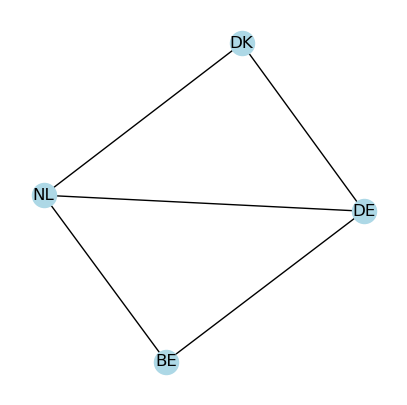

In [15]:
fig, ax = plt.subplots(figsize=(5, 5))
nx.draw(G, with_labels=True, ax=ax, node_color="lightblue")

In [16]:
incidence_matrix = nx.incidence_matrix(G, oriented=True, weight=None).todense()
incidence_matrix

array([[-1., -1., -1.,  0.,  0.],
       [ 1.,  0.,  0., -1.,  0.],
       [ 0.,  1.,  0.,  1., -1.],
       [ 0.,  0.,  1.,  0.,  1.]])

In [17]:
# -----------------------------
# 1. INCIDENCE MATRIX (K)
# -----------------------------
K = np.array([
    [-1, -1, -1,  0,  0],  # NL
    [ 1,  0,  0, -1,  0],  # DK
    [ 0,  1,  0,  1, -1],  # DE
    [ 0,  0,  1,  0,  1]   # BE
], dtype=float)

print("K =\n", K)


# -----------------------------
# 2. SUSCEPTANCE MATRIX (B)
# -----------------------------
x = 0.1
B = (1/x) * np.eye(K.shape[1])

print("\nB =\n", B)



print("\nK_T =\n", K.T)

# -----------------------------
# 3. LAPLACIAN (L = K B K^T)
# Gives the same result with the two approaches
# -----------------------------

#L = K @ B @ K.T
L =10 * K @ K.T
print("\nL =\n", L)


# -----------------------------
# 4. REDUCED LAPLACIAN (SLACK NODE)
# -----------------------------
# BE is slack → index 3
slack = 3

mask = [i for i in range(L.shape[0]) if i != slack]
L_reduced = L[np.ix_(mask, mask)]

print("\nL_reduced =\n", L_reduced)


# -----------------------------
# 5. INVERSE OF REDUCED LAPLACIAN
# -----------------------------
L_reduced_inv = np.linalg.inv(L_reduced)

print("\nL_reduced_inv =\n", L_reduced_inv)


# -----------------------------
# 6. EXPAND BACK TO FULL L^-1
# -----------------------------
L_inv = np.zeros_like(L)

for i, ii in enumerate(mask):
    for j, jj in enumerate(mask):
        L_inv[ii, jj] = L_reduced_inv[i, j]

print("\nL_inv (with slack node) =\n", L_inv)


# -----------------------------
# 7. PTDF MATRIX
# Gives the same result with the two approaches
# -----------------------------

#PTDF = B @ K.T @ L_inv
PTDF = 10 *K.T @ L_inv

print("\nPTDF =\n", PTDF)


# -----------------------------
# 8. INSERT YOUR NODAL BALANCES HERE
# -----------------------------
# IMPORTANT: must sum to zero
p = np.array([
    862,  # NL
    2681,  # DK
    -4262,  # DE
    719   # BE
])

# -----------------------------
# 9. LINE FLOWS
# -----------------------------
p_l = PTDF @ p

print("\nLine flows p_l =\n", p_l)

K =
 [[-1. -1. -1.  0.  0.]
 [ 1.  0.  0. -1.  0.]
 [ 0.  1.  0.  1. -1.]
 [ 0.  0.  1.  0.  1.]]

B =
 [[10.  0.  0.  0.  0.]
 [ 0. 10.  0.  0.  0.]
 [ 0.  0. 10.  0.  0.]
 [ 0.  0.  0. 10.  0.]
 [ 0.  0.  0.  0. 10.]]

K_T =
 [[-1.  1.  0.  0.]
 [-1.  0.  1.  0.]
 [-1.  0.  0.  1.]
 [ 0. -1.  1.  0.]
 [ 0.  0. -1.  1.]]

L =
 [[ 30. -10. -10. -10.]
 [-10.  20. -10.   0.]
 [-10. -10.  30. -10.]
 [-10.   0. -10.  20.]]

L_reduced =
 [[ 30. -10. -10.]
 [-10.  20. -10.]
 [-10. -10.  30.]]

L_reduced_inv =
 [[0.0625 0.05   0.0375]
 [0.05   0.1    0.05  ]
 [0.0375 0.05   0.0625]]

L_inv (with slack node) =
 [[0.0625 0.05   0.0375 0.    ]
 [0.05   0.1    0.05   0.    ]
 [0.0375 0.05   0.0625 0.    ]
 [0.     0.     0.     0.    ]]

PTDF =
 [[-1.25000000e-01  5.00000000e-01  1.25000000e-01  0.00000000e+00]
 [-2.50000000e-01 -4.16333634e-17  2.50000000e-01  0.00000000e+00]
 [-6.25000000e-01 -5.00000000e-01 -3.75000000e-01  0.00000000e+00]
 [-1.25000000e-01 -5.00000000e-01  1.25000000e-01  0.0

In [18]:
sum_p = np.sum(p)
print("\nSum of nodal balances (should be zero) =", sum_p)


Sum of nodal balances (should be zero) = 0


## f)
### Sensitivity to CO2 constraint

In [19]:
df_results_co2 = []

CO2_limits = range(0, 51_000_000, 1_000_000)  # tons of CO2

year = 2015

for limit in CO2_limits:
    
    # Create model for the year
    nco2 = create_network(year, df_NLD)

    # Set snapshots to current year
    snapshots = CF_onshore.loc[str(year)].index.tz_localize(None)
    nco2.set_snapshots(snapshots)

    # add global constraint on CO2 emissions
    nco2.add(
        "GlobalConstraint",
        "co2Limit",
        #type="primary_energy",
        carrier_attribute="co2_emissions",
        sense="<=",
        constant=limit,
    )

    nco2.add("StorageUnit",
            name="battery",
            carrier="battery",
            bus="NLD",
            p_nom_extendable=True,
            max_hours=battery_hours,
            capital_cost=CAPEX_per_kW,
            marginal_cost=0,
            efficiency_store=0.95,
            efficiency_dispatch=0.95)

    # --- Solve optimization ---
    nco2.optimize(solver_name="gurobi",
                  solver_options={"LogToConsole": 0, "OutputFlag": 0},
                  progress=False)

    # --- Record results ---
    df_results_co2.append({
        "year": year,
        "co2Limit": limit/1e6, # million tons
        "system_cost": nco2.objective/1e9, # billion euros
        "onshore_capacity": nco2.generators.p_nom_opt["NLD onshore wind"],
        "offshore_capacity": nco2.generators.p_nom_opt["NLD offshore wind"],
        "solar_capacity": nco2.generators.p_nom_opt["NLD solar"],
        "coal_capacity": nco2.generators.p_nom_opt["NLD coal"],
        "gas_capacity": nco2.generators.p_nom_opt["NLD gas"],
        "battery_capacity": nco2.storage_units.p_nom_opt["battery"]
    })

# Convert to DataFrame
df_results_co2 = pd.DataFrame(df_results_co2)

Index(['battery'], dtype='str', name='name')


Set parameter Username
Set parameter LicenseID to value 2706901
Academic license - for non-commercial use only - expires 2026-09-10
Read LP format model from file C:\Users\s223865\AppData\Local\Temp\linopy-problem-mj9okwk8.lp
Reading time = 0.49 seconds
obj: 157687 rows, 70086 columns, 319734 nonzeros
Set parameter LogToConsole to value 0


Index(['battery'], dtype='str', name='name')


Set parameter Username
Set parameter LicenseID to value 2706901
Academic license - for non-commercial use only - expires 2026-09-10
Read LP format model from file C:\Users\s223865\AppData\Local\Temp\linopy-problem-fzhke9s_.lp
Reading time = 0.38 seconds
obj: 157687 rows, 70086 columns, 319734 nonzeros
Set parameter LogToConsole to value 0


Index(['battery'], dtype='str', name='name')


...

Set parameter Username
Set parameter LicenseID to value 2706901
Academic license - for non-commercial use only - expires 2026-09-10
Read LP format model from file C:\Users\s223865\AppData\Local\Temp\linopy-problem-bey9col0.lp
Reading time = 0.88 seconds
obj: 157687 rows, 70086 columns, 319734 nonzeros
Set parameter LogToConsole to value 0


Index(['battery'], dtype='str', name='name')


Set parameter Username
Set parameter LicenseID to value 2706901
Academic license - for non-commercial use only - expires 2026-09-10
Read LP format model from file C:\Users\s223865\AppData\Local\Temp\linopy-problem-_nrpbo0c.lp
Reading time = 2.16 seconds
obj: 157687 rows, 70086 columns, 319734 nonzeros
Set parameter LogToConsole to value 0


Index(['battery'], dtype='str', name='name')


Set parameter Username
Set parameter LicenseID to value 2706901
Academic license - for non-commercial use only - expires 2026-09-10
Read LP format model from file C:\Users\s223865\AppData\Local\Temp\linopy-problem-pxpj4g_d.lp
Reading time = 13.39 seconds
obj: 157687 rows, 70086 columns, 319734 nonzeros
Set parameter LogToConsole to value 0


#### Plot

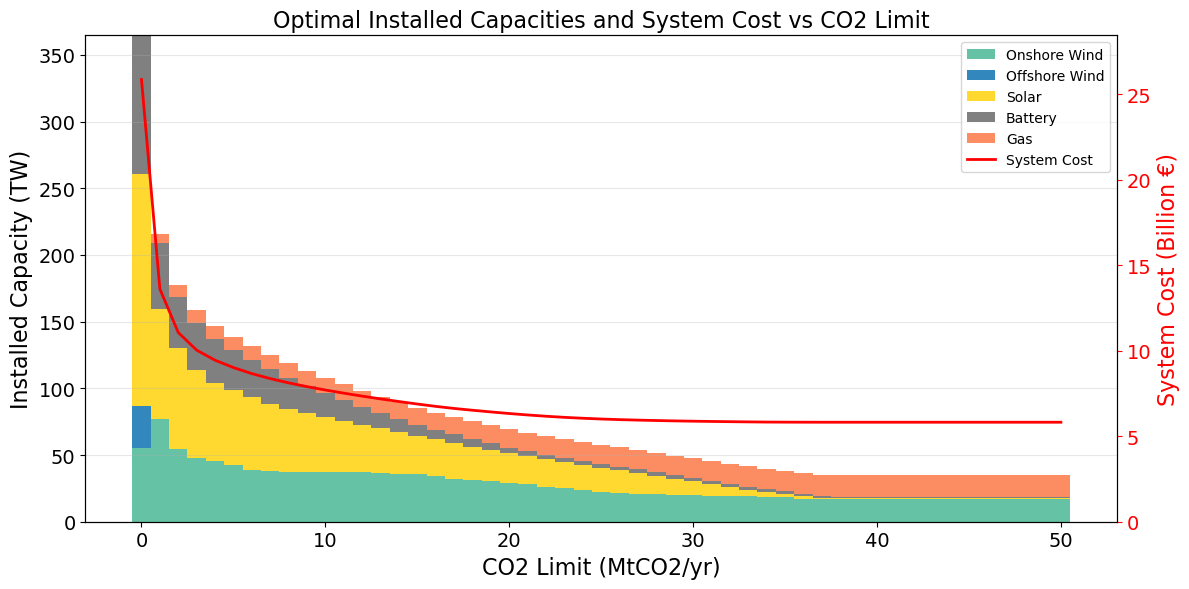

In [20]:
x = df_results_co2["co2Limit"]

carrier_colors["battery"] = "grey"

fig, ax = plt.subplots(figsize=(12,6))

bottom = np.zeros(len(df_results_co2))

techs = [
    ("onshore_capacity", "Onshore Wind", "Wind_onshore"),
    ("offshore_capacity", "Offshore Wind", "Wind_offshore"),
    ("solar_capacity", "Solar", "Solar"),
    ("battery_capacity", "Battery", "battery"),
    ("coal_capacity", "Coal", "Coal"),
    ("gas_capacity", "Gas", "Gas")
]

# --- Stacked bars (primary axis) ---
for col, label, color_key in techs:
    values = df_results_co2[col] / 1000

    if values.sum() > 0:
        ax.bar(
            x,
            values,
            bottom=bottom,
            label=label,
            color=carrier_colors[color_key],
            width=1
        )
        bottom += values

# --- Secondary axis for system cost ---
ax2 = ax.twinx()

ax2.plot(
    x,
    df_results_co2["system_cost"],
    color="red",
    marker="",
    linewidth=2,
    label="System Cost"
)

# --- Labels ---
ax.set_xlabel("CO2 Limit (MtCO2/yr)", fontsize=16)
ax.set_ylabel("Installed Capacity (TW)", fontsize=16)
ax2.set_ylabel("System Cost (Billion €)", fontsize=16, color="red")

# --- Styling ---
ax.tick_params(labelsize=14)
ax2.tick_params(labelsize=14, colors="red")
ax2.set_ylim(0, df_results_co2["system_cost"].max() * 1.1)

ax.grid(True, axis="y", alpha=0.3)

# --- Combined legend ---
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

plt.title("Optimal Installed Capacities and System Cost vs CO2 Limit", fontsize=16)
plt.tight_layout()
plt.show()

## g)
### gas transport network

In [21]:
# Copying model from part d
nd.model_solver = None
ng = nd.copy()

# Adding gas busses for each country
ng.add("Bus", "NLD_gas", carrier="Gas")
ng.add("Bus", "DEU_gas", carrier="Gas")
ng.add("Bus", "BEL_gas", carrier="Gas")
ng.add("Bus", "DNK_gas", carrier="Gas")

# Adding gas links between each country
ng.add("Link", "link DNK-NLD", bus0 = "DNK_gas", bus1 = "NLD_gas", p_nom = 0, p_min_pu = -1) # Line 1
ng.add("Link", "link DEU-NLD", bus0 = "DEU_gas", bus1 = "NLD_gas", s_nom = cap_DEU_NLD, x=x_react, r=r_resis) # Line 2
ng.add("Link", "link BEL-NLD", bus0 = "BEL_gas", bus1 = "NLD_gas", s_nom = cap_BEL_NLD, x=x_react, r=r_resis) # Line 3
ng.add("Link", "link DEU-DNK", bus0 = "DEU_gas", bus1 = "DNK_gas", s_nom = cap_DEU_DNK, x=x_react, r=r_resis) # Line 4
ng.add("Link", "link BEL-DEU", bus0 = "BEL_gas", bus1 = "DEU_gas", s_nom = cap_BEL_DEU, x=x_react, r=r_resis) # Line 5



ValueError: Copying a solved network with an attached solver model is not supported. Please delete the model first using `n.model.solver_model = None`.

## i)
### Adding the transportation sector

In [18]:
nd.model.solver_model = None
ni = nd.copy()

availability_factor = 0.3 * 14/24 # Assuming 30% of battery is allowed to be used and that the EVs are connected 14 hr/day on average
C_rate = 11/62 # Assuming 11 kW chargers and 62 kWh battery capacity for EVs

# Adding a "free" battery from the EVs of each country
EV_data = {
    "DNK": 32.9*(10**3)*availability_factor*C_rate,   # MW
    "DEU": 571.03*(10**3)*availability_factor*C_rate,   # MW
    "BEL": 71.49*(10**3)*availability_factor*C_rate,  # MW
    "NLD": 106.92*(10**3)*availability_factor*C_rate,   # MW
}

for country, p_nom in EV_data.items():
    gen_name = f"EV_battery_{country}"
    ni.add("StorageUnit",
           name=gen_name,
           carrier="EV_battery",
           bus=country,
           p_nom=p_nom,
           p_nom_extendable=False,
           max_hours=1/C_rate,
           capital_cost=0,
           marginal_cost=2,
           efficiency_store=0.95,
           efficiency_dispatch=0.95)


ni.optimize()



Index(['Biofuel_DEU', 'Biofuel_DNK', 'Nuclear_BEL'], dtype='str', name='name')
Index(['EV_battery_DNK', 'EV_battery_DEU', 'EV_battery_BEL', 'EV_battery_NLD'], dtype='str', name='name')
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 98.81it/s]


('ok', 'unknown')

In [19]:
print(round(ni.generators.groupby(["bus", "carrier"])["p_nom_opt"].sum(),0))

bus  carrier      
BEL  Gas               3519.0
     Nuclear           9813.0
     Solar                0.0
     Wind_offshore        0.0
     Wind_onshore         0.0
DEU  Biofuel              0.0
     Coal                 0.0
     Gas              80310.0
     Solar                0.0
     Wind_offshore        0.0
     Wind_onshore     62244.0
DNK  Biofuel           1604.0
     Coal                 0.0
     Solar                0.0
     Wind_offshore        0.0
     Wind_onshore     11663.0
NLD  Coal                 0.0
     Gas              13906.0
     Solar                0.0
     Wind_offshore        0.0
     Wind_onshore     21276.0
Name: p_nom_opt, dtype: float64


In [ ]:
# Power (MW) and energy capacity (MWh) of storage units grouped by bus & carrier
storage = ni.storage_units
power = storage.groupby(["bus", "carrier"])["p_nom_opt"].sum()
energy = (storage["p_nom_opt"] * storage["max_hours"]).groupby([storage["bus"], storage["carrier"]]).sum()

df_storage_cap = pd.concat([power.rename("p_nom_opt_MW"), energy.rename("energy_capacity_MWh")], axis=1).fillna(0).round(3)
df_storage_cap

,,p_nom_opt_MW,energy_capacity_MWh
bus,carrier,,
BEL,EV_battery,2219.649,12510.75
DEU,EV_battery,17729.560,99930.25
DNK,EV_battery,1021.492,5757.50
NLD,EV_battery,3319.694,18711.00


In [ ]:
# Sanity check installed EV battery size
# 530,600 EVs in Denmark
print("Denmark should have approximately", 530600*0.3*(14/24)*11*10**-3, "MW and" , 530600*0.3*(14/24)*62*10**-3, "MWh of EV battery capacity")

Denmark should have approximately 1021.405 MW and 5757.01 MWh of EV battery capacity


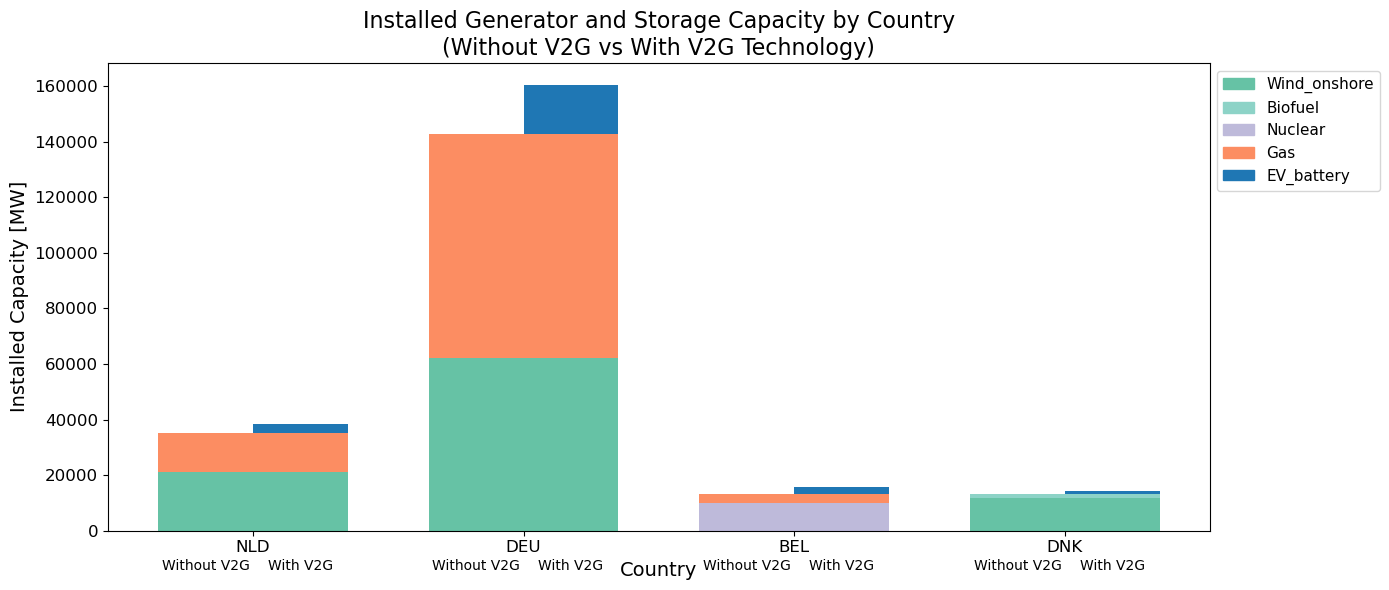

Country    Scenario  CO2 emissions [MtCO2]  Total system cost [B€]
    NLD Without V2G                 33.100                  37.825
    DEU Without V2G                180.634                  37.825
    BEL Without V2G                  3.042                  37.825
    DNK Without V2G                  0.000                  37.825
    NLD    With V2G                 33.100                   0.000
    DEU    With V2G                180.634                   0.000
    BEL    With V2G                  3.042                   0.000
    DNK    With V2G                  0.000                   0.000


In [ ]:
# bar plot of generation and storage capacities by carrier for each country comparing the system in section D without V2G and this section with V2G

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define colors and stack order
carrier_colors = {
    "Wind_onshore": "#66c2a5",
    "Wind_offshore": "#3288bd",
    "Solar": "#ffd92f",
    "Gas": "#fc8d62",
    "Coal": "#4d4d4d",
    "Biofuel": "#8dd3c7",
    "Nuclear": "#bebada",
    "EV_battery": "#1f77b4",
}

stack_order = ["Wind_onshore", "Wind_offshore", "Solar", "Biofuel", "Nuclear", "Coal", "Gas", "EV_battery"]

countries = ["NLD", "DEU", "BEL", "DNK"]
x_pos = np.arange(len(countries))
width = 0.35

# Collect data for both scenarios
data_d = {}  # Without V2G (section D)
data_i = {}  # With V2G (section i)

# Extract generator capacities from nd (without V2G)
for country in countries:
    gens_country = nd.generators[nd.generators.bus == country]
    data_d[country] = gens_country.groupby("carrier")["p_nom_opt"].sum()

# Extract generator and storage unit capacities from ni (with V2G)
for country in countries:
    gens_country = ni.generators[ni.generators.bus == country]
    storage_country = ni.storage_units[ni.storage_units.bus == country]

    # Combine generators and storage units
    gen_cap = gens_country.groupby("carrier")["p_nom_opt"].sum()
    storage_cap = storage_country.groupby("carrier")["p_nom_opt"].sum()

    data_i[country] = pd.concat([gen_cap, storage_cap])

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Plot bars for each country
for i, country in enumerate(countries):
    # Without EV scenario
    bottom_d = 0
    for carrier in stack_order:
        value = data_d[country].get(carrier, 0)
        if value > 0:
            ax.bar(
                x_pos[i] - width / 2,
                value,
                width,
                bottom=bottom_d,
                label=carrier if i == 0 else "",
                color=carrier_colors.get(carrier, "gray"),
            )
            bottom_d += value

    # With EV scenario
    bottom_i = 0
    for carrier in stack_order:
        value = data_i[country].get(carrier, 0)
        if value > 0:
            ax.bar(
                x_pos[i] + width / 2,
                value,
                width,
                bottom=bottom_i,
                label=carrier if i == 0 else "",
                color=carrier_colors.get(carrier, "gray"),
            )
            bottom_i += value

# Customize plot
ax.set_xlabel("Country", fontsize=14)
ax.set_ylabel("Installed Capacity [MW]", fontsize=14)
ax.set_title("Installed Generator and Storage Capacity by Country\n(Without V2G vs With V2G Technology)", fontsize=16)
ax.set_xticks(x_pos)
ax.set_xticklabels(countries, fontsize=12)
ax.tick_params(axis="y", labelsize=12)

# Create custom legend using only carriers that are actually installed in at least one scenario
installed_carriers = []
for carrier in stack_order:
    if any(data_d[country].get(carrier, 0) > 0 for country in countries) or any(data_i[country].get(carrier, 0) > 0 for country in countries):
        installed_carriers.append(carrier)

handles = [plt.Rectangle((0, 0), 1, 1, color=carrier_colors.get(c, "gray")) for c in installed_carriers]
labels = installed_carriers
ax.legend(handles, labels, loc="upper left", bbox_to_anchor=(1, 1), fontsize=11)

# Add text to indicate scenarios
for x in x_pos:
    ax.text(x - width / 2, -0.06, "Without V2G", transform=ax.get_xaxis_transform(), fontsize=10, ha="center", va="top")
    ax.text(x + width / 2, -0.06, "With V2G", transform=ax.get_xaxis_transform(), fontsize=10, ha="center", va="top")

plt.tight_layout()
plt.show()

# Print CO2 emissions and total system cost for both scenarios
summary_rows = []
scenarios = [("Without V2G", nd), ("With V2G", ni)]

for scenario_name, network in scenarios:
    total_system_cost_beur = network.objective / 1e9
    generator_dispatch = network.generators_t.p

    for country in countries:
        country_generators = network.generators.index[network.generators.bus == country]
        country_emissions_tons = 0.0

        for generator_name in country_generators:
            carrier = network.generators.at[generator_name, "carrier"]
            co2_factor = network.carriers["co2_emissions"].get(carrier, 0)
            co2_factor = 0 if pd.isna(co2_factor) else float(co2_factor)
            country_emissions_tons += generator_dispatch[generator_name].sum() * co2_factor

        summary_rows.append({
            "Country": country,
            "Scenario": scenario_name,
            "CO2 emissions [MtCO2]": country_emissions_tons / 1e6,
            "Total system cost [B€]": total_system_cost_beur,
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False, float_format=lambda value: f"{value:,.3f}"))

# j)

### Scenario with 100% EVs and no gas allowed

In [20]:
# Task j: 100% EVs and no gas allowed
total_cars = 9076146 + 2792614 + 6069063 + 48474741
extra_demand_twh = total_cars * 0.81 * 2400 * 10**-9
total_demand_twh = 113.3 + 32.8 + 85.2 + 505.3
share_of_total_demand = extra_demand_twh / total_demand_twh

print("Task j - EV scenario")
print("-" * 32)
print(f"Total cars in the 4 countries: {total_cars:,}")
print(f"Additional annual electricity demand from EV charging: {extra_demand_twh:.2f} TWh")
print(f"Total 2015 electricity demand in the 4 countries: {total_demand_twh:.1f} TWh")
print(f"Additional demand as share of total demand: {share_of_total_demand:.1%}")

Task j - EV scenario
--------------------------------
Total cars in the 4 countries: 66,412,564
Additional annual electricity demand from EV charging: 129.11 TWh
Total 2015 electricity demand in the 4 countries: 736.6 TWh
Additional demand as share of total demand: 17.5%


In [21]:
nd.model.solver_model = None
# Create two models (with and without V2G) to compare the results
# First without V2G
nj_noV2G = nd.copy()

# Increase the Electricity demand by 17.5% to account for the additional demand from EVs
countries = ["NLD", "DEU", "BEL", "DNK"]
for country in countries:
    load_name = f"{country} load"
    if load_name in nj_noV2G.loads.index:
        nj_noV2G.loads.at[load_name, "p_set"] *= (1 + share_of_total_demand)

# Remove the option for gas in the system
for gen in nj_noV2G.generators.index:
    if nj_noV2G.generators.at[gen, "carrier"] == "Gas":
        nj_noV2G.generators.at[gen, "p_nom_extendable"] = False
        nj_noV2G.generators.at[gen, "p_nom"] = 0

# Copy and add the V2G
nj_V2G = nj_noV2G.copy()

availability_factor = 0.3 * 14/24 # Assuming 30% of battery is allowed to be used and that the EVs are connected 14 hr/day on average
C_rate = 11/62 # Assuming 11 kW chargers and 62 kWh battery capacity for EVs
increase_factor = 100/19 # To scale up the amount of EVs af passenger cars (assuming 19% in the base case)
# Adding a "free" battery from the EVs of each country to the network with V2G
EV_data = {
    "DNK": 32.9*(10**3)*availability_factor*C_rate*increase_factor,   # MW
    "DEU": 571.03*(10**3)*availability_factor*C_rate*increase_factor,   # MW
    "BEL": 71.49*(10**3)*availability_factor*C_rate*increase_factor,  # MW
    "NLD": 106.92*(10**3)*availability_factor*C_rate*increase_factor,   # MW
}

for country, p_nom in EV_data.items():
    gen_name = f"EV_battery_{country}"
    nj_V2G.add("StorageUnit",
           name=gen_name,
           carrier="EV_battery",
           bus=country,
           p_nom=p_nom,
           p_nom_extendable=False,
           max_hours=1/C_rate,
           capital_cost=0,
           marginal_cost=2,
           efficiency_store=0.95,
           efficiency_dispatch=0.95)
    

nj_noV2G.optimize()
nj_V2G.optimize()



Index(['Biofuel_DEU', 'Biofuel_DNK', 'Nuclear_BEL'], dtype='str', name='name')
Writing continuous variables.: 100%|██████████| 3/3 [00:00<00:00, 72.64it/s]
Index(['Biofuel_DEU', 'Biofuel_DNK', 'Nuclear_BEL'], dtype='str', name='name')
Index(['EV_battery_DNK', 'EV_battery_DEU', 'EV_battery_BEL', 'EV_battery_NLD'], dtype='str', name='name')
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 85.04it/s]


('ok', 'unknown')

In [22]:
print(round(nj_noV2G.generators.groupby(["bus", "carrier"])["p_nom_opt"].sum(),0))


bus  carrier      
BEL  Gas                  0.0
     Nuclear           9813.0
     Solar                0.0
     Wind_offshore        0.0
     Wind_onshore         0.0
DEU  Biofuel              0.0
     Coal                 0.0
     Gas                  0.0
     Solar                0.0
     Wind_offshore        0.0
     Wind_onshore     62244.0
DNK  Biofuel           1604.0
     Coal                 0.0
     Solar                0.0
     Wind_offshore        0.0
     Wind_onshore     11663.0
NLD  Coal                 0.0
     Gas                  0.0
     Solar                0.0
     Wind_offshore        0.0
     Wind_onshore     21276.0
Name: p_nom_opt, dtype: float64


In [ ]:
print(round(nj_V2G.generators.groupby(["bus", "carrier"])["p_nom_opt"].sum(),0))

bus  carrier      
BEL  Gas                  0.0
     Nuclear           9813.0
     Solar                0.0
     Wind_offshore        0.0
     Wind_onshore         0.0
DEU  Biofuel              0.0
     Coal                 0.0
     Gas                  0.0
     Solar                0.0
     Wind_offshore        0.0
     Wind_onshore     62244.0
DNK  Biofuel           1604.0
     Coal                 0.0
     Solar                0.0
     Wind_offshore        0.0
     Wind_onshore     11663.0
NLD  Coal                 0.0
     Gas                  0.0
     Solar                0.0
     Wind_offshore        0.0
     Wind_onshore     21276.0
Name: p_nom_opt, dtype: float64


In [ ]:
# Power (MW) and energy capacity (MWh) of storage units grouped by bus & carrier
storage = nj_V2G.storage_units
power = storage.groupby(["bus", "carrier"])["p_nom_opt"].sum()
energy = (storage["p_nom_opt"] * storage["max_hours"]).groupby([storage["bus"], storage["carrier"]]).sum()

df_storage_cap = pd.concat([power.rename("p_nom_opt_MW"), energy.rename("energy_capacity_MWh")], axis=1).fillna(0).round(3)
df_storage_cap

,,p_nom_opt_MW,energy_capacity_MWh
bus,carrier,,
BEL,EV_battery,11682.364,65846.053
DEU,EV_battery,93313.476,525948.684
DNK,EV_battery,5376.273,30302.632
NLD,EV_battery,17472.071,98478.947


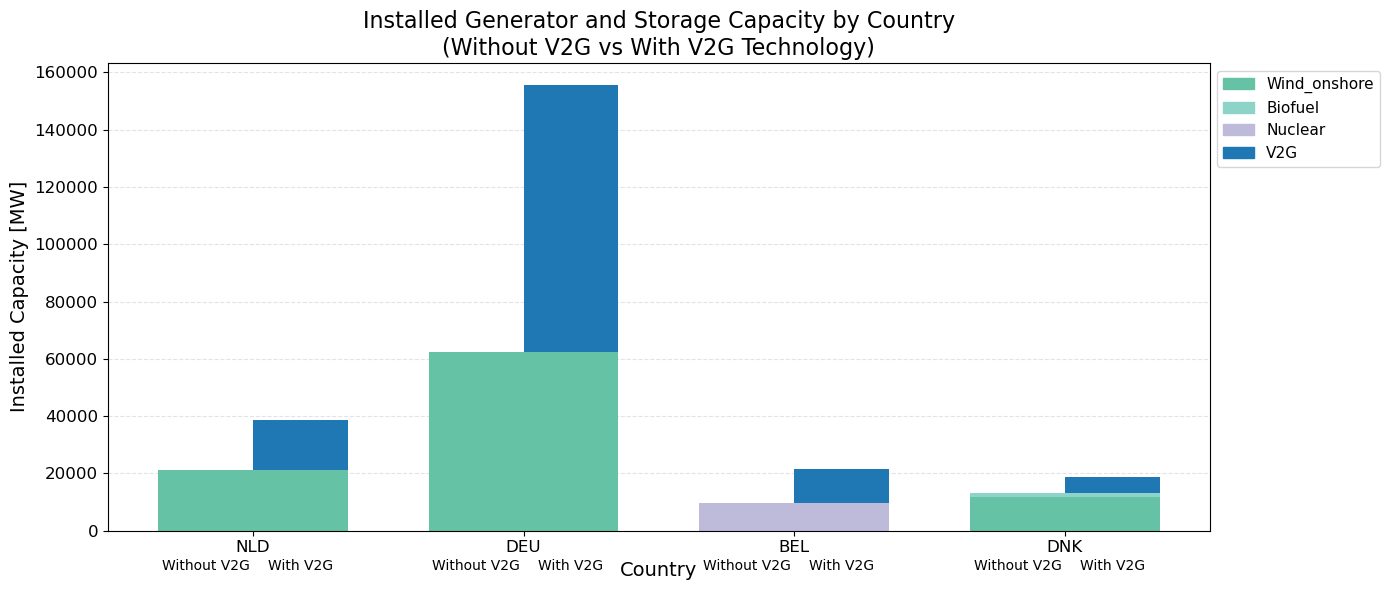

Country    Scenario  CO2 emissions [MtCO2]  Total system cost [B€]
    NLD Without V2G                 33.100                  37.825
    DEU Without V2G                180.634                  37.825
    BEL Without V2G                  3.042                  37.825
    DNK Without V2G                  0.000                  37.825
    NLD    With V2G                 33.100                   0.000
    DEU    With V2G                180.634                   0.000
    BEL    With V2G                  3.042                   0.000
    DNK    With V2G                  0.000                   0.000


In [ ]:
# Comparison plot and summary for Task j

# Define colors for carriers used in this comparison
carrier_colors_j = carrier_colors.copy()
carrier_colors_j["V2G"] = "#1f77b4"
carrier_colors_j["battery"] = "grey"

stack_order_j = ["Wind_onshore", "Wind_offshore", "Solar", "Biofuel", "Nuclear", "Coal", "Gas", "V2G"]

countries = ["NLD", "DEU", "BEL", "DNK"]
x_pos = np.arange(len(countries))
width = 0.35

# Collect generator capacities for both scenarios
cap_no_v2g = {}
cap_v2g = {}

for country in countries:
    gens_no_v2g = nj_noV2G.generators[nj_noV2G.generators.bus == country]
    gens_v2g = nj_V2G.generators[nj_V2G.generators.bus == country]
    storage_v2g = nj_V2G.storage_units[nj_V2G.storage_units.bus == country]

    cap_no_v2g[country] = gens_no_v2g.groupby("carrier")["p_nom_opt"].sum()
    cap_v2g[country] = pd.concat([
        gens_v2g.groupby("carrier")["p_nom_opt"].sum(),
        storage_v2g.groupby("carrier")["p_nom_opt"].sum().rename(index={"EV_battery": "V2G"}),
    ]).groupby(level=0).sum()

fig, ax = plt.subplots(figsize=(14, 6))

for i, country in enumerate(countries):
    bottom_no_v2g = 0
    bottom_v2g = 0

    for carrier in stack_order_j:
        value_no_v2g = cap_no_v2g[country].get(carrier, 0)
        value_v2g = cap_v2g[country].get(carrier, 0)

        if value_no_v2g > 0:
            ax.bar(
                x_pos[i] - width / 2,
                value_no_v2g,
                width,
                bottom=bottom_no_v2g,
                label=carrier if i == 0 else "",
                color=carrier_colors_j.get(carrier, "gray"),
            )
            bottom_no_v2g += value_no_v2g

        if value_v2g > 0:
            ax.bar(
                x_pos[i] + width / 2,
                value_v2g,
                width,
                bottom=bottom_v2g,
                label=carrier if i == 0 else "",
                color=carrier_colors_j.get(carrier, "gray"),
            )
            bottom_v2g += value_v2g

# Customize plot
ax.set_xlabel("Country", fontsize=14)
ax.set_ylabel("Installed Capacity [MW]", fontsize=14)
ax.set_title("Installed Generator and Storage Capacity by Country\n(Without V2G vs With V2G Technology)", fontsize=16)
ax.set_xticks(x_pos)
ax.set_xticklabels(countries, fontsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

# Create custom legend using only carriers that are actually installed in at least one scenario
installed_carriers = []
for carrier in stack_order_j:
    if any(cap_no_v2g[country].get(carrier, 0) > 0 for country in countries) or any(cap_v2g[country].get(carrier, 0) > 0 for country in countries):
        installed_carriers.append(carrier)

handles = [plt.Rectangle((0, 0), 1, 1, color=carrier_colors_j.get(c, "gray")) for c in installed_carriers]
labels = installed_carriers
ax.legend(handles, labels, loc="upper left", bbox_to_anchor=(1, 1), fontsize=11)

# Add text to indicate scenarios
for x in x_pos:
    ax.text(x - width / 2, -0.06, "Without V2G", transform=ax.get_xaxis_transform(), fontsize=10, ha="center", va="top")
    ax.text(x + width / 2, -0.06, "With V2G", transform=ax.get_xaxis_transform(), fontsize=10, ha="center", va="top")

plt.tight_layout()
plt.show()

# Print CO2 emissions and total system cost for both scenarios
summary_rows = []
scenarios = [("Without V2G", nd), ("With V2G", ni)]

for scenario_name, network in scenarios:
    total_system_cost_beur = network.objective / 1e9
    generator_dispatch = network.generators_t.p

    for country in countries:
        country_generators = network.generators.index[network.generators.bus == country]
        country_emissions_tons = 0.0

        for generator_name in country_generators:
            carrier = network.generators.at[generator_name, "carrier"]
            co2_factor = network.carriers["co2_emissions"].get(carrier, 0)
            co2_factor = 0 if pd.isna(co2_factor) else float(co2_factor)
            country_emissions_tons += generator_dispatch[generator_name].sum() * co2_factor

        summary_rows.append({
            "Country": country,
            "Scenario": scenario_name,
            "CO2 emissions [MtCO2]": country_emissions_tons / 1e6,
            "Total system cost [B€]": total_system_cost_beur,
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False, float_format=lambda value: f"{value:,.3f}"))